# Steam Game Reviews Sentiment Analysis

## Project Overview

This project analyzes Steam game reviews using Natural Language Processing (NLP) and Machine Learning techniques.

The main objective is to build a sentiment classification model that predicts whether a Steam review is positive or negative based on its text.

The project also investigates the relationship between AI-generated sentiment scores and the actual positive review rates of games.

### Main Techniques

- Data Cleaning
- Exploratory Data Analysis
- TF-IDF Vectorization
- Logistic Regression
- Linear Support Vector Machine (SVM)
- Model Evaluation
- Game-Level Sentiment Analysis
- Error Analysis
- Threshold Optimization

## 1. Dataset Loading

The dataset contains Steam game reviews and information related to the games and user recommendations.

The main variables used in this project are:

- `name`: Game name
- `review`: Review text
- `voted_up`: Steam recommendation label
- `word_count`: Number of words in the review

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("../data/steam_game_reviews_730945.csv")

In [14]:
df.shape

(730945, 11)

In [15]:
df.head()

,appid,review,word_count,voted_up,votes_up,votes_funny,timestamp_created,author_playtime_forever,name,price,release_date
0,1938090,I really loved the game but itll take you a lo...,26,True,0,0,1757864825,1485,Call of Duty: Modern Warfare II,6999,NaN
1,1938090,i cant join the game for some reason,8,False,0,0,1757864289,346,Call of Duty: Modern Warfare II,6999,NaN
2,1938090,these new games are just living in the MASSIVE...,133,False,0,0,1757861908,2131,Call of Duty: Modern Warfare II,6999,NaN
3,1938090,Its fun of course you have cheaters but beside...,25,True,0,0,1757854957,344,Call of Duty: Modern Warfare II,6999,NaN
4,1938090,I play this game as a casual player on PC. I h...,39,False,0,1,1757846859,1746,Call of Duty: Modern Warfare II,6999,NaN


In [16]:
df.columns

Index(['appid', 'review', 'word_count', 'voted_up', 'votes_up', 'votes_funny',
       'timestamp_created', 'author_playtime_forever', 'name', 'price',
       'release_date'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730945 entries, 0 to 730944
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   appid                    730945 non-null  int64  
 1   review                   730945 non-null  str    
 2   word_count               730945 non-null  int64  
 3   voted_up                 730945 non-null  bool   
 4   votes_up                 730945 non-null  int64  
 5   votes_funny              730945 non-null  int64  
 6   timestamp_created        730945 non-null  int64  
 7   author_playtime_forever  730945 non-null  int64  
 8   name                     730945 non-null  str    
 9   price                    730945 non-null  int64  
 10  release_date             0 non-null       float64
dtypes: bool(1), float64(1), int64(7), str(2)
memory usage: 56.5 MB


In [18]:
df = df.drop(columns=["release_date"])

In [19]:
df.shape

(730945, 10)

In [20]:
df["voted_up"].value_counts()

voted_up
True     597717
False    133228
Name: count, dtype: int64

In [21]:
df["voted_up"].value_counts(normalize=True)

voted_up
True     0.817732
False    0.182268
Name: proportion, dtype: float64

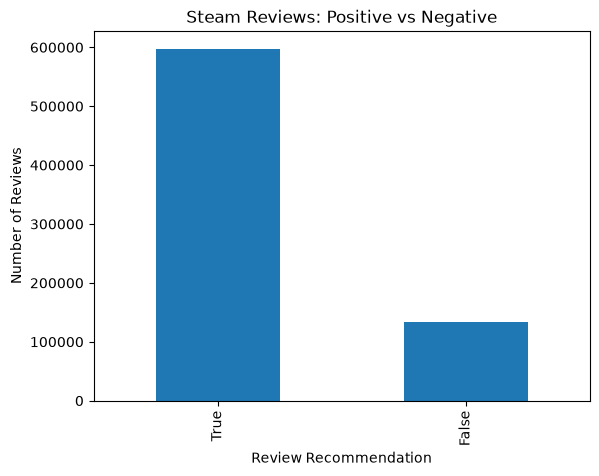

In [ ]:
df["voted_up"].value_counts().plot(kind="bar")

plt.title("Steam Reviews: Positive vs Negative")
plt.xlabel("Review Recommendation")
plt.ylabel("Number of Reviews")
plt.show()

In [23]:
df["review"].describe()

count                                                730945
unique                                               721521
top       ⠄⠄⣿⣿⣿⣿⠘⡿⢛⣿⣿⣿⣿⣿⣧⢻⣿⣿⠃⠸⣿⣿⣿⠄⠄⠄⠄⠄\n⠄⠄⣿⣿⣿⣿⢀⠼⣛⣛⣭⢭⣟⣛⣛⣛...
freq                                                    121
Name: review, dtype: object

In [24]:
df["word_count"].describe()

count    730945.000000
mean         57.174641
std         111.375654
min           6.000000
25%          11.000000
50%          22.000000
75%          53.000000
max        2667.000000
Name: word_count, dtype: float64

In [ ]:
df.loc[df["word_count"].idxmin(), "review"]

'they ban me for no reason.'

In [26]:
df.loc[df["word_count"].idxmax(), "review"]

'67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 67 

In [27]:
df.duplicated().sum()

np.int64(2)

In [28]:
df["review"].duplicated().sum()

np.int64(9424)

In [29]:
df[df["review"].duplicated(keep=False)][["name", "review", "voted_up"]].head(10)

,name,review,voted_up
399,Call of Duty: Modern Warfare II,Fun game to play with friends.,True
632,Call of Duty: Modern Warfare II,best game i have ever played,True
860,Call of Duty: Modern Warfare II,"I am a 45 yo father, probably one of the oldes...",True
1905,New World: Aeternum,Disable Steam cookies @ [url]https://store.ste...,False
1912,New World: Aeternum,fun game with lots to do,True
2067,Black Myth: Wukong,One of the best games i've ever played!,True
2163,Black Myth: Wukong,Shut up and take my money!,True
2277,Black Myth: Wukong,One of the best games that I have played,True
2295,Black Myth: Wukong,I really really love this game,True
2365,Black Myth: Wukong,⣿⣿⣿⣿⣿⠟⠋⠄⠄⠄⠄⠄⠄⠄⢁⠈⢻⢿⣿⣿⣿⣿⣿⣿⣿\n⣿⣿⣿⣿⣿⠃⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠈⡀...,True


In [31]:
df = df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
import re

numeric_only = df["review"].str.fullmatch(r"\s*\d+(?:\s+\d+)*\s*")

numeric_only.sum()

np.int64(12)

In [34]:
(df["word_count"] > 500).sum()

np.int64(9258)

In [35]:
(df["word_count"] <= 5).sum()

np.int64(0)

In [36]:
df = df[~numeric_only].copy()

In [37]:
df.shape

(730931, 10)

In [38]:
symbol_heavy = df["review"].str.count(r"[A-Za-zÀ-ÿ]") < 5
symbol_heavy.sum()

np.int64(4287)

In [39]:
df.loc[symbol_heavy, ["name", "review", "word_count", "voted_up"]].head(20)

,name,review,word_count,voted_up
572,Call of Duty: Modern Warfare II,كيف ارجع لعبه في ستيم: شروط استرداد الألعاب في...,46,True
869,Call of Duty: Modern Warfare II,"沙比游戏, 全是挂. 要不就是动不动崩溃, 玩勾八. 使劲买皮肤花你妈大几千就配打个僵尸....",8,False
2066,Black Myth: Wukong,⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀...,31,True
2365,Black Myth: Wukong,⣿⣿⣿⣿⣿⠟⠋⠄⠄⠄⠄⠄⠄⠄⢁⠈⢻⢿⣿⣿⣿⣿⣿⣿⣿\n⣿⣿⣿⣿⣿⠃⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠈⡀...,13,True
2537,Black Myth: Wukong,⡴⠑⡄⠀⠀⠀⠀⠀⠀⠀⣀⣀⣤⣤⣤⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀\r\n⠸⡇⠀⠿⡀⠀⠀⠀⣀⡴⢿⣿⣿...,14,True
2868,Black Myth: Wukong,Создателю босса первой главы обязательно в пос...,46,True
3120,Monster Hunter Wilds,هذا أول جزء أجربه من السلسلة وللأمانة استمتعت ...,69,True
3385,Monster Hunter Wilds,⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀\r\n⠀⠀⠀⠀⠀⠀⠀⠀⣾⣿⠟⢻⡀⠀⠀⠀⠀⠀⠀⠀⠀...,13,True
4072,ELDEN RING,⠀⠀⠀⠀⠀⠀⠀⢀⠠⠤⠤⠤⠤⠤⠄⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀\n⠀⠀⠀⠀⠀⡠⠊⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀...,14,True
4077,ELDEN RING,⣿⣿⢿⠛⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿...,17,True


In [40]:
df.loc[symbol_heavy, ["name", "review", "word_count", "voted_up"]].sample(20, random_state=42)

,name,review,word_count,voted_up
233517,Enshrouded,⠀ ⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⣀⣀⣀⠀⠀⠀⠀⠀⠀...,26,True
508843,DRAGON BALL XENOVERSE,⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠘⣷⣶⣤⣄⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀...,32,True
557254,STAR WARS - The Force Unleashed Ultimate Sith ...,⠀⠀⠀⠀⠀⣠⣴⣶⣯⠪⣕⢶⣦⣔⢄⠀⠀\n⠀⠀⠀⢀⣼⣿⣿⣿⣿⣧⡙⣧⢹⣿⣷⣇⠀\n⠀⠀⠀⣸⣿⣿⣿⣿...,11,True
667307,"Papers, Please",⠀⠀⠀⠀⢀⣀⣀⣀⣀⣀⣀⣀⣀⣀⣀⣀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣀⠀⠀⠀⠀⠀⢀⣀⣀⣀⣀⣀⣀⣀⣀⣀⣀⣀⠀⠀...,7,True
640200,POSTAL 2,Это идеальная игра для того что бы выплеснуть пар,9,True
626242,Geometry Dash,Что может быть лучше первого уровня?,6,True
436916,Crysis Warhead,Обосрался от акулы 10 лет назад\n10 из 10 лучш...,32,True
709596,The Binding of Isaac,"шутер где надо стрелять в какашки, настоящый ш...",8,True
545569,Paint the Town Red,اقسم بالله ممتعه بشكل ماتوقعته \r\n10/10,6,True
127814,Half-Life 2: Deathmatch,смертельная скука с пластиковым оружием и уныл...,18,False


In [43]:
has_letters = df["review"].str.contains(r"[^\W\d_]", regex=True)

has_letters.value_counts()

review
True     729534
False      1397
Name: count, dtype: int64

In [44]:
df.loc[~has_letters, ["name", "review", "word_count", "voted_up"]].shape

(1397, 4)

In [45]:
df.loc[~has_letters, ["name", "review", "word_count", "voted_up"]].head(30)

,name,review,word_count,voted_up
2066,Black Myth: Wukong,⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀...,31,True
2365,Black Myth: Wukong,⣿⣿⣿⣿⣿⠟⠋⠄⠄⠄⠄⠄⠄⠄⢁⠈⢻⢿⣿⣿⣿⣿⣿⣿⣿\n⣿⣿⣿⣿⣿⠃⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠈⡀...,13,True
2537,Black Myth: Wukong,⡴⠑⡄⠀⠀⠀⠀⠀⠀⠀⣀⣀⣤⣤⣤⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀\r\n⠸⡇⠀⠿⡀⠀⠀⠀⣀⡴⢿⣿⣿...,14,True
3385,Monster Hunter Wilds,⠀⠀⠀⠀⠀⠀⠀⠀⠀⣀⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀\r\n⠀⠀⠀⠀⠀⠀⠀⠀⣾⣿⠟⢻⡀⠀⠀⠀⠀⠀⠀⠀⠀...,13,True
4072,ELDEN RING,⠀⠀⠀⠀⠀⠀⠀⢀⠠⠤⠤⠤⠤⠤⠄⣀⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀\n⠀⠀⠀⠀⠀⡠⠊⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀...,14,True
4077,ELDEN RING,⣿⣿⢿⠛⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿...,17,True
4212,ELDEN RING,⠀⡇⡇⠀ ⠀⠀⡇\n⠀⠀⠀⡆⡇⠀ ⠀⠀⡇⡄\n⠀⠀⠀⠁⡇⠇⠀⡂⡇⡇\n⠀⠀⠀⡇⣇⠃⠀⣇⣁⡇\...,27,True
4430,ELDEN RING,⣿⣿⣿⣿⣿⣿⠿⠉⠉⠉⠉⠉⠉⠉⠟⠉⠉⠉⠉⠉⢹⣿⠿⡉⡉⠉⠉⠉⠉⠉⠉⠉⠉⢉⣉⡙⢿⣿⣿⣿⣀⣈⢿⣛⣭⣽...,19,True
6368,Cyberpunk 2077,⣿⣿⣿⣿⣿⠟⠋⠄⠄⠄⠄⠄⠄⠄⢁⠈⢻⢿⣿⣿⣿⣿⣿⣿⣿\r\n⣿⣿⣿⣿⣿⠃⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄...,13,True
6427,Cyberpunk 2077,⣿⣿⣿⣿⣿⡿⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⢿⣿⣿⣿⣿\n⣿⣿⣿⣿⡏⣀⠀⠀⠀⠀⠀⠀⠀⣀...,24,True


In [46]:
df = df[has_letters].copy()

In [47]:
df.shape

(729534, 10)

In [48]:
df["voted_up"].value_counts()

voted_up
True     596366
False    133168
Name: count, dtype: int64

In [49]:
df["voted_up"].value_counts(normalize=True)

voted_up
True     0.817462
False    0.182538
Name: proportion, dtype: float64

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X = df["review"]
y = df["voted_up"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain dağılımı:")
print(y_train.value_counts(normalize=True))

print("\nTest dağılımı:")
print(y_test.value_counts(normalize=True))

Train: (583627,)
Test: (145907,)

Train dağılımı:
voted_up
True     0.817462
False    0.182538
Name: proportion, dtype: float64

Test dağılımı:
voted_up
True     0.817459
False    0.182541
Name: proportion, dtype: float64


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [56]:
tfidf = TfidfVectorizer(
    max_features=50000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

In [57]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [58]:
X_test_tfidf = tfidf.transform(X_test)

In [59]:
print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Train TF-IDF: (583627, 50000)
Test TF-IDF: (145907, 50000)


In [60]:
from sklearn.linear_model import LogisticRegression

In [66]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [62]:
model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [63]:
y_pred = model.predict(X_test_tfidf)

In [64]:
print(y_pred[:20])

[ True  True  True  True  True False False  True  True  True  True  True
  True False False  True  True  True False  True]


In [67]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8986820371880718

Classification Report:
              precision    recall  f1-score   support

       False       0.67      0.89      0.76     26634
        True       0.97      0.90      0.94    119273

    accuracy                           0.90    145907
   macro avg       0.82      0.89      0.85    145907
weighted avg       0.92      0.90      0.90    145907



In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [69]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 23578   3056]
 [ 11727 107546]]


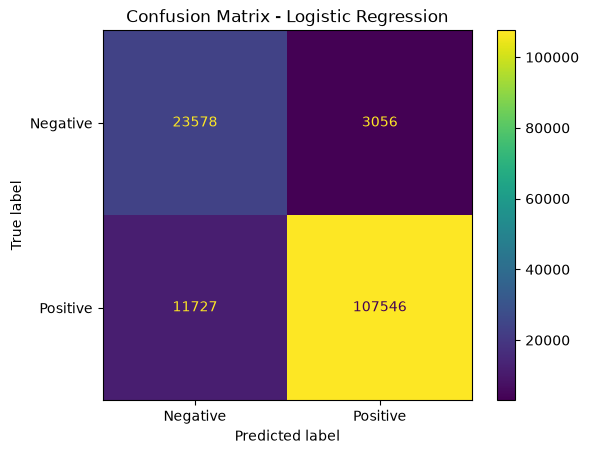

In [70]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [75]:
# Modeli tekrar eğit
model.fit(X_train_tfidf, y_train)

# Olasılıkları al
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# ROC-AUC hesapla
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9593010532059713


In [76]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9000253586188462

Classification Report:
              precision    recall  f1-score   support

       False       0.68      0.86      0.76     26634
        True       0.97      0.91      0.94    119273

    accuracy                           0.90    145907
   macro avg       0.82      0.89      0.85    145907
weighted avg       0.91      0.90      0.90    145907



In [77]:
from sklearn.metrics import roc_auc_score

y_score_svm = svm_model.decision_function(X_test_tfidf)

roc_auc_svm = roc_auc_score(y_test, y_score_svm)

print("SVM ROC-AUC:", roc_auc_svm)

SVM ROC-AUC: 0.9557178087097906


In [78]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [0.9000, 0.8987],
    "ROC-AUC": [0.9593, 0.9557]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.9000,0.9593
1,SVM,0.8987,0.9557


In [79]:
results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.9000,0.9593
1,SVM,0.8987,0.9557


In [80]:
df["name"].nunique()

735

In [81]:
df["name"].value_counts().head(20)

name
Call of Duty: Modern Warfare 3 (2011)    1996
Total War: SHOGUN 2                      1996
Call of Duty: Modern Warfare 2 (2009)    1995
Call of Duty: Black Ops II               1994
Call of Duty: Black Ops                  1988
Counter-Strike: Condition Zero           1925
Call of Duty: Ghosts                     1533
Medal of Honor                           1023
Call of Duty: Modern Warfare II          1000
New World: Aeternum                      1000
Baldur's Gate 3                          1000
Red Dead Redemption 2                    1000
Battlefield 2042                         1000
7 Days to Die                            1000
Mount & Blade II: Bannerlord             1000
Sid Meier’s Civilization VI              1000
Battlefield V                            1000
DayZ                                     1000
Call of Duty: Black Ops III              1000
EA SPORTS FC 24                          1000
Name: count, dtype: int64

In [85]:
game_counts = df["name"].value_counts()

game_counts.describe()

count     735.000000
mean      992.563265
std       139.640960
min         1.000000
25%       997.000000
50%       999.000000
75%      1000.000000
max      1996.000000
Name: count, dtype: float64

In [86]:
game_counts.sort_values().head(20)

name
Heart of a Warrior                      1
Sabre Team                              4
Sid Meier's Civilization IV            27
Civilization IV: Beyond the Sword      38
Strobophagia | Rave Horror             79
CyberCorp                             142
Jack Orlando: Director's Cut          172
The I of the Dragon                   265
Capcom Arcade 2nd Stadium             302
The Scroll Of Taiwu                   362
Company of Heroes: Opposing Fronts    432
Fortified                             563
Murderous Pursuits                    686
暖雪 Warm Snow                          813
Back to Bed                           822
Braveland                             887
Love Is All Around                    919
Divide By Sheep                       955
Crysis 3 Remastered                   960
The Descendant                        969
Name: count, dtype: int64

In [87]:
game_counts = df["name"].value_counts()

valid_games = game_counts[game_counts >= 100].index

df_games = df[df["name"].isin(valid_games)].copy()

print("Toplam oyun:", df["name"].nunique())
print("Analize alınan oyun:", df_games["name"].nunique())
print("Toplam yorum:", len(df_games))

Toplam oyun: 735
Analize alınan oyun: 730
Toplam yorum: 729385


In [88]:
X_sample = tfidf.transform(df_games["review"].head(10000))

y_sample_prob = model.predict_proba(X_sample)[:, 1]

y_sample_prob[:10]

array([0.9742982 , 0.17942473, 0.25403161, 0.81001211, 0.01589053,
       0.0146019 , 0.08600894, 0.94181042, 0.45319816, 0.33393149])

In [89]:
import numpy as np

batch_size = 10000
all_probabilities = []

for start in range(0, len(df_games), batch_size):
    end = min(start + batch_size, len(df_games))
    
    reviews_batch = df_games["review"].iloc[start:end]
    
    X_batch = tfidf.transform(reviews_batch)
    
    probabilities = model.predict_proba(X_batch)[:, 1]
    
    all_probabilities.extend(probabilities)
    
    print(f"{end:,} / {len(df_games):,} işlendi")

10,000 / 729,385 işlendi
20,000 / 729,385 işlendi
30,000 / 729,385 işlendi
40,000 / 729,385 işlendi
50,000 / 729,385 işlendi
60,000 / 729,385 işlendi
70,000 / 729,385 işlendi
80,000 / 729,385 işlendi
90,000 / 729,385 işlendi
100,000 / 729,385 işlendi
110,000 / 729,385 işlendi
120,000 / 729,385 işlendi
130,000 / 729,385 işlendi
140,000 / 729,385 işlendi
150,000 / 729,385 işlendi
160,000 / 729,385 işlendi
170,000 / 729,385 işlendi
180,000 / 729,385 işlendi
190,000 / 729,385 işlendi
200,000 / 729,385 işlendi
210,000 / 729,385 işlendi
220,000 / 729,385 işlendi
230,000 / 729,385 işlendi
240,000 / 729,385 işlendi
250,000 / 729,385 işlendi
260,000 / 729,385 işlendi
270,000 / 729,385 işlendi
280,000 / 729,385 işlendi
290,000 / 729,385 işlendi
300,000 / 729,385 işlendi
310,000 / 729,385 işlendi
320,000 / 729,385 işlendi
330,000 / 729,385 işlendi
340,000 / 729,385 işlendi
350,000 / 729,385 işlendi
360,000 / 729,385 işlendi
370,000 / 729,385 işlendi
380,000 / 729,385 işlendi
390,000 / 729,385 işl

In [90]:
len(all_probabilities)

729385

In [91]:
df_games["ai_sentiment_score"] = all_probabilities

In [92]:
df_games[["name", "review", "voted_up", "ai_sentiment_score"]].head(10)

,name,review,voted_up,ai_sentiment_score
0,Call of Duty: Modern Warfare II,I really loved the game but itll take you a lo...,True,0.974298
1,Call of Duty: Modern Warfare II,i cant join the game for some reason,False,0.179425
2,Call of Duty: Modern Warfare II,these new games are just living in the MASSIVE...,False,0.254032
3,Call of Duty: Modern Warfare II,Its fun of course you have cheaters but beside...,True,0.810012
4,Call of Duty: Modern Warfare II,I play this game as a casual player on PC. I h...,False,0.015891
5,Call of Duty: Modern Warfare II,shit game i downloaded 120 gb for nothing to b...,False,0.014602
6,Call of Duty: Modern Warfare II,the gameplay is super fun but everything else ...,False,0.086009
7,Call of Duty: Modern Warfare II,Its very fun but makes your DAMN computer lag\r\n,True,0.941810
8,Call of Duty: Modern Warfare II,dont you dare click the download button\r\n,False,0.453198
9,Call of Duty: Modern Warfare II,i dont get why people hate bo6 or warzone so m...,True,0.333931


In [93]:
df_games["ai_sentiment_score"].describe()

count    7.293850e+05
mean     7.172464e-01
std      3.396019e-01
min      4.306146e-07
25%      5.232008e-01
50%      8.938757e-01
75%      9.790566e-01
max      9.999997e-01
Name: ai_sentiment_score, dtype: float64

In [94]:
game_stats = df_games.groupby("name").agg(
    review_count=("review", "count"),
    ai_sentiment_score=("ai_sentiment_score", "mean"),
    actual_positive_rate=("voted_up", "mean")
).reset_index()

game_stats.head()

,name,review_count,ai_sentiment_score,actual_positive_rate
0,7 Days to Die,1000,0.531447,0.548000
1,A Dance of Fire and Ice,999,0.810022,0.915916
2,A Plague Tale: Innocence,999,0.826049,0.903904
3,A Story About My Uncle,998,0.760100,0.855711
4,A Way Out,998,0.778128,0.853707


In [95]:
top_games = game_stats.sort_values(
    "ai_sentiment_score",
    ascending=False
)

top_games.head(20)

,name,review_count,ai_sentiment_score,actual_positive_rate
531,STAR WARS Empire at War - Gold Pack,1000,0.891645,0.966000
590,Stray,996,0.891426,0.944779
583,Stardew Valley,996,0.888271,0.980924
201,Dishonored,998,0.880279,0.956914
627,The Henry Stickmin Collection,998,0.879606,0.979960
565,Slime Rancher,999,0.878577,0.971972
56,Batman: Arkham City - Game of the Year Edition,997,0.874520,0.964895
715,Wobbly Life,999,0.873773,0.963964
123,Clair Obscur: Expedition 33,999,0.873387,0.963964
394,Marvel’s Spider-Man Remastered,1000,0.872831,0.945000


In [99]:
game_stats["score_difference"] = (
    game_stats["ai_sentiment_score"]
    - game_stats["actual_positive_rate"]
)

In [97]:
game_stats.sort_values(
    "score_difference",
    ascending=False
).head(10)

,name,review_count,ai_sentiment_score,actual_positive_rate,score_difference
59,BattleBit Remastered,1000,0.279721,0.255000,0.024721
86,Borderlands: The Pre-Sequel,999,0.233727,0.230230,0.003497
107,Call of Duty: Modern Warfare II,1000,0.390005,0.388000,0.002005
580,Squad,1000,0.295166,0.300000,-0.004834
719,Wolfenstein: Youngblood,999,0.341210,0.347347,-0.006138
603,TEKKEN 8,997,0.447667,0.455366,-0.007699
0,7 Days to Die,1000,0.531447,0.548000,-0.016553
139,Creativerse,1000,0.352280,0.376000,-0.023720
318,Hero Siege,1000,0.421483,0.450000,-0.028517
8,ARK: Survival Evolved,1000,0.457985,0.489000,-0.031015


In [98]:
game_stats.sort_values(
    "score_difference",
    ascending=True
).head(10)

,name,review_count,ai_sentiment_score,actual_positive_rate,score_difference
375,Lossless Scaling,999,0.687009,0.913914,-0.226905
373,Lobotomy Corporation | Monster Management Simu...,1000,0.738763,0.960000,-0.221237
141,Cruelty Squad,999,0.737321,0.937938,-0.200617
602,TEKKEN 7,993,0.686098,0.866062,-0.179965
275,Getting Over It with Bennett Foddy,998,0.652750,0.832665,-0.179915
308,Half-Life 2: Lost Coast,998,0.723063,0.902806,-0.179742
454,PAYDAY The Heist,994,0.758266,0.929577,-0.171312
133,Cookie Clicker,996,0.773330,0.943775,-0.170445
222,EARTH DEFENSE FORCE 4.1 The Shadow of New Despair,1000,0.781463,0.945000,-0.163537
137,Counter-Strike: Source,998,0.774194,0.936874,-0.162680


In [101]:
print(df.shape)
print(df.columns.tolist())

(729534, 10)
['appid', 'review', 'word_count', 'voted_up', 'votes_up', 'votes_funny', 'timestamp_created', 'author_playtime_forever', 'name', 'price']


In [102]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LinearSVC                type                      <class 'sklearn.svm._classes.LinearSVC'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RocCurveDisplay          type                      <class 'sklearn.metrics._<...>c_curve.RocCurveDisplay'>
TfidfVectorizer          type                      <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
X                        Series                    Shape: (729534,)
X_batch                  csr_matrix                <Compressed Sparse Row sp<...>49702)	0.3479917674468835
X_sample                 csr_matrix                <Compressed Sparse Row sp<...>9843)	0.10250414216682338
X_test                   Series                    Shape: (145907,)
X_test_t

In [103]:
df_games.columns


Index(['appid', 'review', 'word_count', 'voted_up', 'votes_up', 'votes_funny',
       'timestamp_created', 'author_playtime_forever', 'name', 'price',
       'ai_sentiment_score'],
      dtype='str')

In [104]:
lossless_reviews = df_games[
    df_games["name"] == "Lossless Scaling"
][["review", "voted_up", "ai_sentiment_score"]]

lossless_reviews.head(20)

,review,voted_up,ai_sentiment_score
682117,It does what it sets out to do.,True,0.902469
682118,Felt like I had IG premium & just everything p...,True,0.052483
682119,Best piece of software if your pc is a little ...,True,0.885297
682120,it makes my game slightly worse,False,0.257654
682121,Very easy and simple to use.,True,0.859995
682122,Not good but not bad. but way better than AMD ...,True,0.863550
682123,IN my bedroom PC I have a RTX 3050 Lossless Sc...,True,0.641592
682124,Makes my skyrim run poorly. On 4090 and 13900k,False,0.156344
682125,"As advertised, this is an incredible product. ...",True,0.732801
682126,okay this is what i found out ab this for VR w...,True,0.268406


In [105]:
lossless_reviews["actual"] = lossless_reviews["voted_up"].astype(int)

lossless_reviews["error"] = abs(
    lossless_reviews["actual"] - lossless_reviews["ai_sentiment_score"]
)

lossless_reviews.sort_values(
    "error",
    ascending=False
).head(20)

,review,voted_up,ai_sentiment_score,actual,error
682552,Turned Elden Ring on my laptop (GTX1650) from ...,True,0.009835,1,0.990165
682634,miracle software\nmakes unplayable games playable,True,0.014236,1,0.985764
683110,3.2版本有严重的兼容性问题导致无法使用，主要表现为缩放卡死，缩放后黑屏，缩放结束后，鼠标指...,True,0.019750,1,0.980250
682144,was good but recent updates have caused issues...,True,0.024966,1,0.975034
682731,cant play any ue5 games without it.,True,0.030178,1,0.969822
682920,Allows you to play unplayable games specially ...,True,0.044743,1,0.955257
682680,Literally buying fps. Cant play anymore withou...,True,0.045142,1,0.954858
682399,"Not work on every game, but when it work its f...",True,0.045673,1,0.954327
682820,It literally feels like magic. Went from 30 to...,True,0.045984,1,0.954016
682795,Download more FPS 100% NO SCAM,True,0.049980,1,0.950020


In [106]:
model.classes_


array([False,  True])

In [109]:
test_reviews = [
    "miracle software makes unplayable games playable",
    "It literally feels like magic",
    "Absolutely great, I bought this specifically",
    "it makes my game slightly worse",
    "Makes my skyrim run poorly"
]

test_tfidf = tfidf.transform(test_reviews)

test_probs = model.predict_proba(test_tfidf)[:, 1]

for review, prob in zip(test_reviews, test_probs):
    print(f"{prob:.4f} -> {review}")

0.0142 -> miracle software makes unplayable games playable
0.3685 -> It literally feels like magic
0.9398 -> Absolutely great, I bought this specifically
0.2577 -> it makes my game slightly worse
0.1895 -> Makes my skyrim run poorly


In [110]:
df_games["ai_predicted"] = (
    df_games["ai_sentiment_score"] >= 0.5
)

In [111]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    df_games["voted_up"],
    df_games["ai_predicted"]
))

              precision    recall  f1-score   support

       False       0.68      0.91      0.78    133151
        True       0.98      0.91      0.94    596234

    accuracy                           0.91    729385
   macro avg       0.83      0.91      0.86    729385
weighted avg       0.92      0.91      0.91    729385



In [112]:
cm = confusion_matrix(
    df_games["voted_up"],
    df_games["ai_predicted"]
)

print(cm)

[[120615  12536]
 [ 56123 540111]]


In [113]:
df_games["error"] = abs(
    df_games["voted_up"].astype(int)
    - df_games["ai_sentiment_score"]
)

In [114]:
worst_predictions = df_games.sort_values(
    "error",
    ascending=False
)[[
    "name",
    "review",
    "voted_up",
    "ai_sentiment_score",
    "error"
]]

worst_predictions.head(20)

,name,review,voted_up,ai_sentiment_score,error
156278,Sea of Thieves: 2025 Edition,Broken login – game is unplayable\n\nI used to...,True,0.000029,0.999971
716535,Town of Salem,"Oh boy, where do I even begin with this dumpst...",True,0.000107,0.999893
704369,Natural Selection 2,It's a good game. I love it.,False,0.999889,0.999889
694668,Dark Messiah of Might & Magic,what a masterpiece its a timeless cl,False,0.999862,0.999862
214404,The Witcher 2: Assassins of Kings Enhanced Edi...,recommending for now.. but that may well chang...,True,0.000243,0.999757
426829,NARUTO TO BORUTO: SHINOBI STRIKER,"This game is hell on earth, one of the worst o...",True,0.000291,0.999709
545918,Paint the Town Red,Good game beneath game mode is horrible legit ...,True,0.000301,0.999699
216918,Enter the Gungeon,terrible dont play not fun will regret dpnt bu...,True,0.000321,0.999679
638922,Portal 2,great game lots of fun 1/10 would definitely p...,False,0.999659,0.999659
107719,STAR WARS Jedi: Survivor,DO NOT BUY THE DELUXE DLC!!!!!! Absolute waste...,True,0.000345,0.999655


In [115]:
game_analysis = df_games.groupby("name").agg(
    review_count=("review", "count"),
    actual_positive_rate=("voted_up", "mean"),
    ai_sentiment_score=("ai_sentiment_score", "mean")
)

game_analysis["score_difference"] = (
    game_analysis["ai_sentiment_score"]
    - game_analysis["actual_positive_rate"]
)

In [116]:
game_analysis.sort_values(
    "score_difference"
).head(10)

,review_count,actual_positive_rate,ai_sentiment_score,score_difference
name,,,,
Lossless Scaling,999,0.913914,0.687009,-0.226905
Lobotomy Corporation | Monster Management Simulation,1000,0.960000,0.738763,-0.221237
Cruelty Squad,999,0.937938,0.737321,-0.200617
TEKKEN 7,993,0.866062,0.686098,-0.179965
Getting Over It with Bennett Foddy,998,0.832665,0.652750,-0.179915
Half-Life 2: Lost Coast,998,0.902806,0.723063,-0.179742
PAYDAY The Heist,994,0.929577,0.758266,-0.171312
Cookie Clicker,996,0.943775,0.773330,-0.170445
EARTH DEFENSE FORCE 4.1 The Shadow of New Despair,1000,0.945000,0.781463,-0.163537


In [117]:
game_analysis.sort_values(
    "score_difference",
    ascending=False
).head(10)

,review_count,actual_positive_rate,ai_sentiment_score,score_difference
name,,,,
BattleBit Remastered,1000,0.255000,0.279721,0.024721
Borderlands: The Pre-Sequel,999,0.230230,0.233727,0.003497
Call of Duty: Modern Warfare II,1000,0.388000,0.390005,0.002005
Squad,1000,0.300000,0.295166,-0.004834
Wolfenstein: Youngblood,999,0.347347,0.341210,-0.006138
TEKKEN 8,997,0.455366,0.447667,-0.007699
7 Days to Die,1000,0.548000,0.531447,-0.016553
Creativerse,1000,0.376000,0.352280,-0.023720
Hero Siege,1000,0.450000,0.421483,-0.028517


In [120]:
game_analysis.head()

,name,review_count,actual_positive_rate,ai_sentiment_score,score_difference
0,7 Days to Die,1000,0.548000,0.531447,-0.016553
1,A Dance of Fire and Ice,999,0.915916,0.810022,-0.105894
2,A Plague Tale: Innocence,999,0.903904,0.826049,-0.077855
3,A Story About My Uncle,998,0.855711,0.760100,-0.095611
4,A Way Out,998,0.853707,0.778128,-0.075579


In [121]:
top_positive_games = game_analysis.sort_values(
    "actual_positive_rate",
    ascending=False
).head(15)

top_positive_games

,name,review_count,actual_positive_rate,ai_sentiment_score,score_difference
583,Stardew Valley,996,0.980924,0.888271,-0.092652
627,The Henry Stickmin Collection,998,0.979960,0.879606,-0.100354
479,Portal 2,999,0.978979,0.868508,-0.110471
478,Portal,998,0.977956,0.870512,-0.107444
476,Plants vs. Zombies GOTY Edition,996,0.977912,0.851702,-0.126210
242,Factorio,1000,0.977000,0.828039,-0.148961
466,People Playground,1000,0.974000,0.867020,-0.106980
686,ULTRAKILL,998,0.973948,0.826701,-0.147247
565,Slime Rancher,999,0.971972,0.878577,-0.093395
30,Aseprite,997,0.971916,0.863857,-0.108058


In [122]:
top_negative_games = game_analysis.sort_values(
    "actual_positive_rate",
    ascending=True
).head(15)

top_negative_games

,name,review_count,actual_positive_rate,ai_sentiment_score,score_difference
86,Borderlands: The Pre-Sequel,999,0.230230,0.233727,0.003497
59,BattleBit Remastered,1000,0.255000,0.279721,0.024721
580,Squad,1000,0.300000,0.295166,-0.004834
719,Wolfenstein: Youngblood,999,0.347347,0.341210,-0.006138
85,Borderlands Game of the Year,998,0.373747,0.342627,-0.031120
139,Creativerse,1000,0.376000,0.352280,-0.023720
62,Battlefield 2042,1000,0.377000,0.323410,-0.053590
221,EA SPORTS FC 25,999,0.384384,0.349393,-0.034991
107,Call of Duty: Modern Warfare II,1000,0.388000,0.390005,0.002005
13,ATLAS,998,0.426854,0.380033,-0.046820


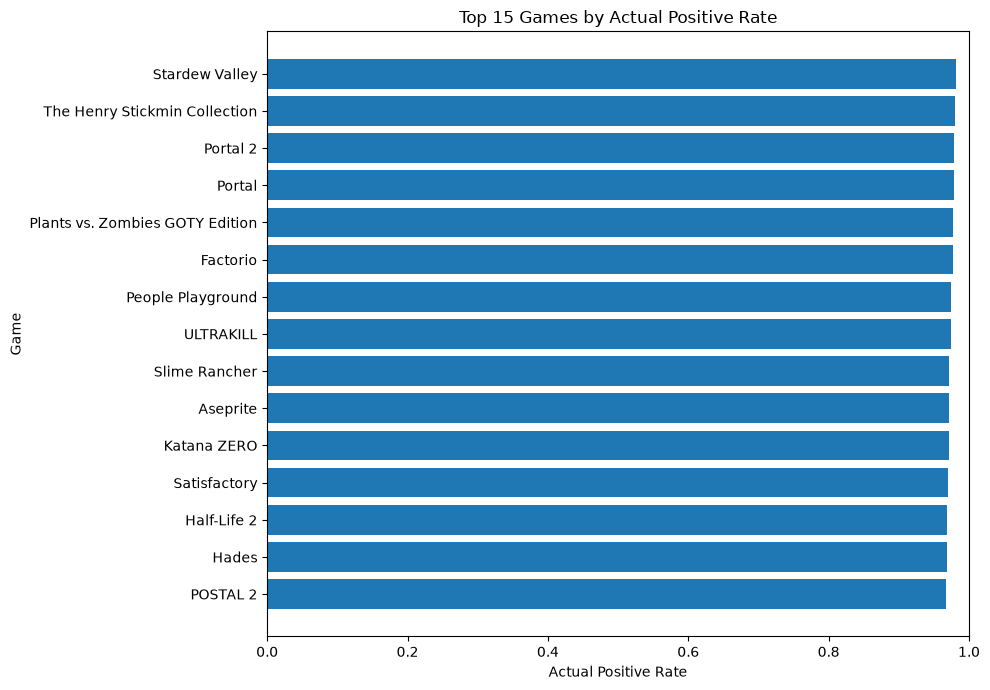

In [123]:
import matplotlib.pyplot as plt

plot_data = top_positive_games.sort_values(
    "actual_positive_rate"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["name"],
    plot_data["actual_positive_rate"]
)

plt.xlabel("Actual Positive Rate")
plt.ylabel("Game")
plt.title("Top 15 Games by Actual Positive Rate")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

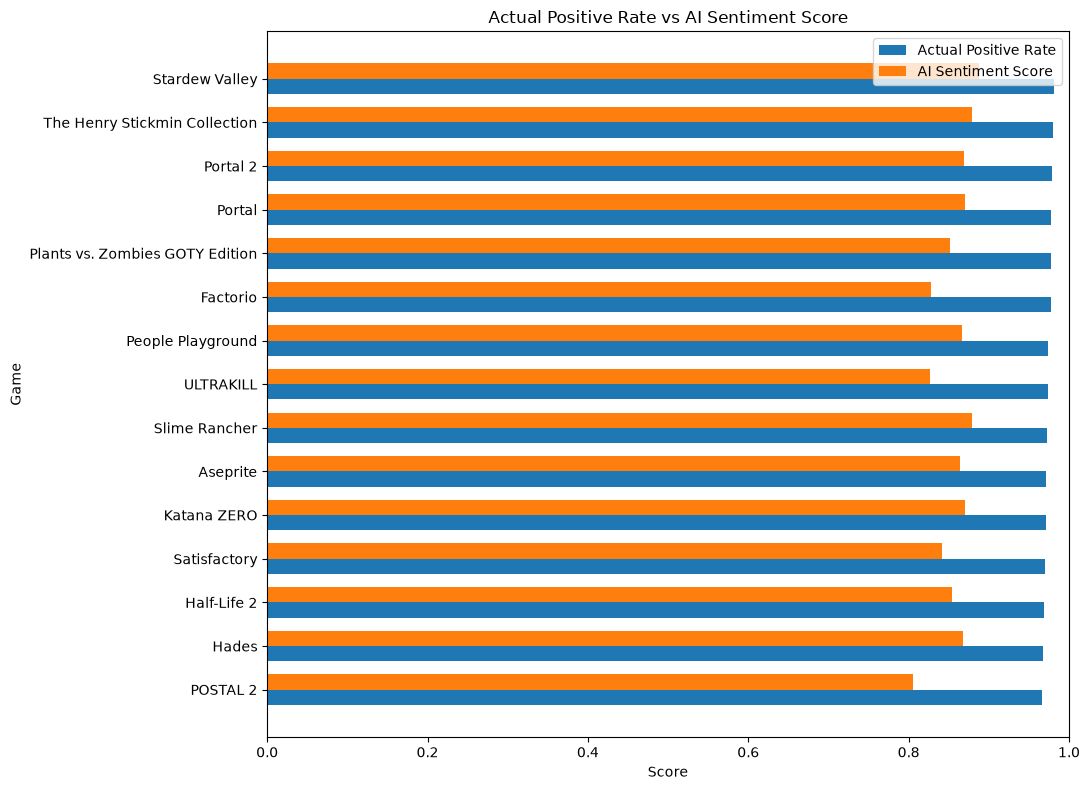

In [124]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = top_positive_games.sort_values(
    "actual_positive_rate"
)

y = np.arange(len(plot_data))
height = 0.35

plt.figure(figsize=(11, 8))

plt.barh(
    y - height/2,
    plot_data["actual_positive_rate"],
    height,
    label="Actual Positive Rate"
)

plt.barh(
    y + height/2,
    plot_data["ai_sentiment_score"],
    height,
    label="AI Sentiment Score"
)

plt.yticks(y, plot_data["name"])
plt.xlabel("Score")
plt.ylabel("Game")
plt.title("Actual Positive Rate vs AI Sentiment Score")
plt.xlim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [126]:
# Oyun bazında analiz
game_analysis = df_games.groupby("name").agg(
    review_count=("voted_up", "count"),
    actual_positive_rate=("voted_up", "mean"),
    ai_sentiment_score=("ai_sentiment_score", "mean")
)

# En az 100 yorum bulunan oyunları al
game_analysis_filtered = game_analysis[
    game_analysis["review_count"] >= 100
].copy()

# AI ile gerçek oran arasındaki fark
game_analysis_filtered["score_difference"] = (
    game_analysis_filtered["ai_sentiment_score"]
    - game_analysis_filtered["actual_positive_rate"]
)

print("Analize alınan oyun:", len(game_analysis_filtered))

game_analysis_filtered.head()

Analize alınan oyun: 730


,review_count,actual_positive_rate,ai_sentiment_score,score_difference
name,,,,
7 Days to Die,1000,0.548000,0.531447,-0.016553
A Dance of Fire and Ice,999,0.915916,0.810022,-0.105894
A Plague Tale: Innocence,999,0.903904,0.826049,-0.077855
A Story About My Uncle,998,0.855711,0.760100,-0.095611
A Way Out,998,0.853707,0.778128,-0.075579


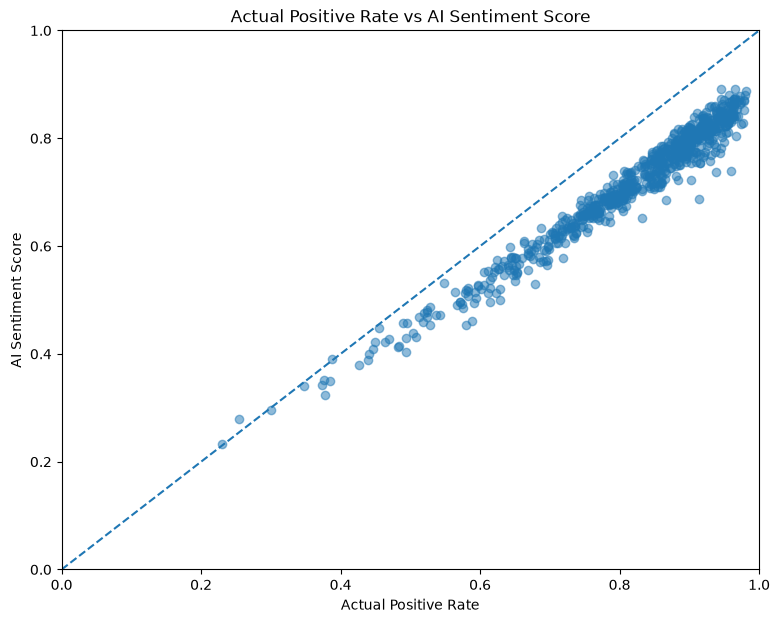

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    game_analysis_filtered["actual_positive_rate"],
    game_analysis_filtered["ai_sentiment_score"],
    alpha=0.5
)

# Mükemmel uyum çizgisi
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual Positive Rate")
plt.ylabel("AI Sentiment Score")
plt.title("Actual Positive Rate vs AI Sentiment Score")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

In [128]:
correlation = game_analysis_filtered[
    ["actual_positive_rate", "ai_sentiment_score"]
].corr().iloc[0, 1]

print("Correlation:", correlation)

Correlation: 0.9823795657976634


In [129]:
mae = game_analysis_filtered["score_difference"].abs().mean()

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.10017181435276548


In [131]:
# Gerçek etiket ile AI tahminini karşılaştır
df_games["error_type"] = "Correct"

df_games.loc[
    (df_games["voted_up"] == True) &
    (df_games["ai_predicted"] == False),
    "error_type"
] = "False Negative"

df_games.loc[
    (df_games["voted_up"] == False) &
    (df_games["ai_predicted"] == True),
    "error_type"
] = "False Positive"

print(df_games["error_type"].value_counts())

error_type
Correct           660726
False Negative     56123
False Positive     12536
Name: count, dtype: int64


In [132]:
error_percentages = (
    df_games["error_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(error_percentages)

error_type
Correct           90.59
False Negative     7.69
False Positive     1.72
Name: proportion, dtype: float64


In [133]:
top_positive = game_analysis.sort_values(
    "actual_positive_rate",
    ascending=False
).head(10)

top_negative = game_analysis.sort_values(
    "actual_positive_rate",
    ascending=True
).head(10)

print("EN POZİTİF OYUNLAR")
display(top_positive)

print("\nEN NEGATİF OYUNLAR")
display(top_negative)

EN POZİTİF OYUNLAR


,review_count,actual_positive_rate,ai_sentiment_score
name,,,
Stardew Valley,996,0.980924,0.888271
The Henry Stickmin Collection,998,0.979960,0.879606
Portal 2,999,0.978979,0.868508
Portal,998,0.977956,0.870512
Plants vs. Zombies GOTY Edition,996,0.977912,0.851702
Factorio,1000,0.977000,0.828039
People Playground,1000,0.974000,0.867020
ULTRAKILL,998,0.973948,0.826701
Slime Rancher,999,0.971972,0.878577



EN NEGATİF OYUNLAR


,review_count,actual_positive_rate,ai_sentiment_score
name,,,
Borderlands: The Pre-Sequel,999,0.230230,0.233727
BattleBit Remastered,1000,0.255000,0.279721
Squad,1000,0.300000,0.295166
Wolfenstein: Youngblood,999,0.347347,0.341210
Borderlands Game of the Year,998,0.373747,0.342627
Creativerse,1000,0.376000,0.352280
Battlefield 2042,1000,0.377000,0.323410
EA SPORTS FC 25,999,0.384384,0.349393
Call of Duty: Modern Warfare II,1000,0.388000,0.390005


In [134]:
game_analysis_filtered["absolute_error"] = (
    game_analysis_filtered["score_difference"].abs()
)

highest_error_games = game_analysis_filtered.sort_values(
    "absolute_error",
    ascending=False
).head(15)

highest_error_games

,review_count,actual_positive_rate,ai_sentiment_score,score_difference,absolute_error
name,,,,,
Lossless Scaling,999,0.913914,0.687009,-0.226905,0.226905
Lobotomy Corporation | Monster Management Simulation,1000,0.960000,0.738763,-0.221237,0.221237
Cruelty Squad,999,0.937938,0.737321,-0.200617,0.200617
TEKKEN 7,993,0.866062,0.686098,-0.179965,0.179965
Getting Over It with Bennett Foddy,998,0.832665,0.652750,-0.179915,0.179915
Half-Life 2: Lost Coast,998,0.902806,0.723063,-0.179742,0.179742
PAYDAY The Heist,994,0.929577,0.758266,-0.171312,0.171312
Cookie Clicker,996,0.943775,0.773330,-0.170445,0.170445
EARTH DEFENSE FORCE 4.1 The Shadow of New Despair,1000,0.945000,0.781463,-0.163537,0.163537


In [135]:
# False Negative ve False Positive yorumları ayır

false_negatives = df_games[
    df_games["error_type"] == "False Negative"
][[
    "name",
    "review",
    "voted_up",
    "ai_sentiment_score"
]].copy()

false_positives = df_games[
    df_games["error_type"] == "False Positive"
][[
    "name",
    "review",
    "voted_up",
    "ai_sentiment_score"
]].copy()

print("False Negative:", len(false_negatives))
print("False Positive:", len(false_positives))

False Negative: 56123
False Positive: 12536


In [136]:
false_negatives["error"] = 1 - false_negatives["ai_sentiment_score"]

fn_worst = false_negatives.sort_values(
    "error",
    ascending=False
)

fn_worst.head(20)

,name,review,voted_up,ai_sentiment_score,error
156278,Sea of Thieves: 2025 Edition,Broken login – game is unplayable\n\nI used to...,True,0.000029,0.999971
716535,Town of Salem,"Oh boy, where do I even begin with this dumpst...",True,0.000107,0.999893
214404,The Witcher 2: Assassins of Kings Enhanced Edi...,recommending for now.. but that may well chang...,True,0.000243,0.999757
426829,NARUTO TO BORUTO: SHINOBI STRIKER,"This game is hell on earth, one of the worst o...",True,0.000291,0.999709
545918,Paint the Town Red,Good game beneath game mode is horrible legit ...,True,0.000301,0.999699
216918,Enter the Gungeon,terrible dont play not fun will regret dpnt bu...,True,0.000321,0.999679
107719,STAR WARS Jedi: Survivor,DO NOT BUY THE DELUXE DLC!!!!!! Absolute waste...,True,0.000345,0.999655
673184,DEVOUR,"Treacherous, disgusting, god awful, unfathomab...",True,0.000409,0.999591
110405,SOULCALIBUR VI,The graphic is awful for its age. The characte...,True,0.000421,0.999579
234841,Kingdom Two Crowns,Laggy beyond belief. Every other second the ga...,True,0.000427,0.999573


In [137]:
false_positives["error"] = false_positives["ai_sentiment_score"]

fp_worst = false_positives.sort_values(
    "error",
    ascending=False
)

fp_worst.head(20)

,name,review,voted_up,ai_sentiment_score,error
704369,Natural Selection 2,It's a good game. I love it.,False,0.999889,0.999889
694668,Dark Messiah of Might & Magic,what a masterpiece its a timeless cl,False,0.999862,0.999862
638922,Portal 2,great game lots of fun 1/10 would definitely p...,False,0.999659,0.999659
728544,Woodle Tree Adventures,Best game i've ever played.\nGraphics-10/10\nS...,False,0.999634,0.999634
70196,Planet Coaster,10/10 game ......\r\nDLCs Equal 1/10\r\n5/10 ...,False,0.999555,0.999555
228257,Grounded,best game ever!I love it so much!,False,0.999520,0.999520
589644,Spelunky,10/10 best game I've ever played,False,0.999372,0.999372
724549,Alan Wake's American Nightmare,i really liked the origanal great story and gr...,False,0.999332,0.999332
534600,Shadow Tactics: Blades of the Shogun,"DO NOT buy this game, you'll regret it. This g...",False,0.999309,0.999309
673011,Who's Your Daddy?!,Very good game very good graphics very good st...,False,0.999089,0.999089


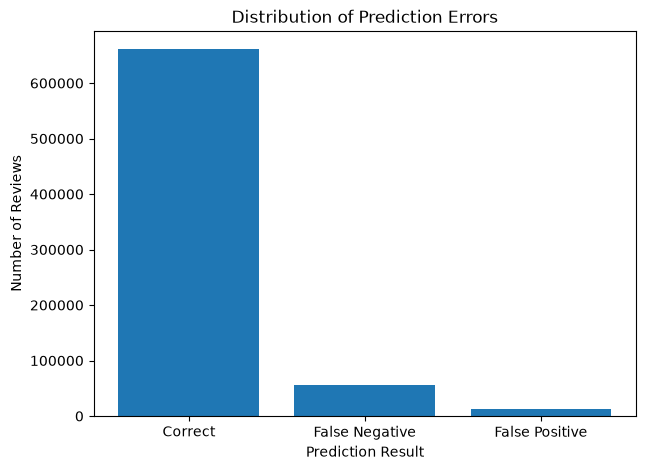

In [138]:
error_counts = df_games["error_type"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    error_counts.index,
    error_counts.values
)

plt.xlabel("Prediction Result")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Prediction Errors")

plt.show()

# Final Model Comparison

Two machine learning models were evaluated for Steam review sentiment classification:

- Logistic Regression
- Linear Support Vector Machine (SVM)

Both models were trained using TF-IDF features with unigrams and bigrams.

Logistic Regression achieved slightly better performance than SVM in both Accuracy and ROC-AUC. Therefore, Logistic Regression was selected as the final model.

In [139]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [0.9000, 0.8987],
    "ROC-AUC": [0.9593, 0.9557]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.9000,0.9593
1,SVM,0.8987,0.9557


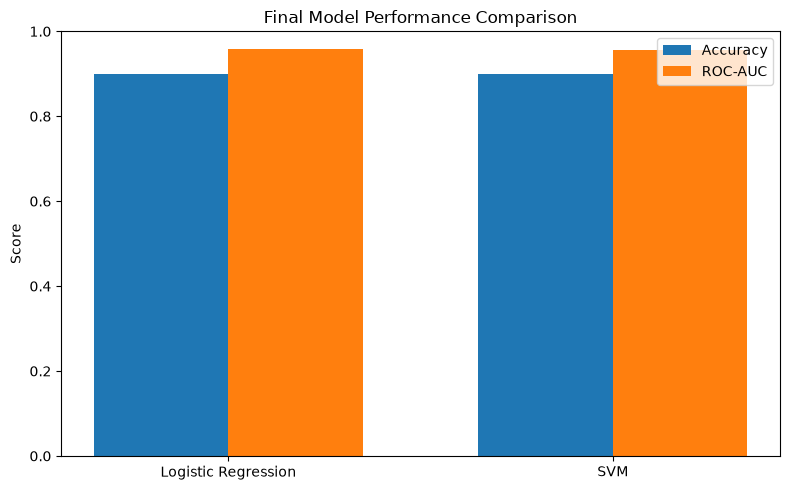

In [140]:
plt.figure(figsize=(8, 5))

x = np.arange(len(results))
width = 0.35

plt.bar(
    x - width/2,
    results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    results["ROC-AUC"],
    width,
    label="ROC-AUC"
)

plt.xticks(x, results["Model"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

# Final Results

The Logistic Regression model achieved an Accuracy of 90.00% and a ROC-AUC score of 0.9593.

The Linear SVM model achieved an Accuracy of 89.87% and a ROC-AUC score of 0.9557.

Although both models performed very well, Logistic Regression slightly outperformed SVM. Therefore, Logistic Regression was selected as the final sentiment classification model.

The model was then used to calculate sentiment scores for Steam reviews. These scores were aggregated at the game level to compare AI-based sentiment with the actual positive review rate.

# Game-Level Sentiment Analysis

The game-level analysis showed a very strong relationship between the AI sentiment score and the actual positive review rate.

The correlation between these two variables was:

**0.9824**

The Mean Absolute Error (MAE) was:

**0.1002**

The high correlation indicates that the AI sentiment scores generally follow the overall positive review rates of games.

However, the difference between the two measures also shows that sentiment classification and Steam recommendation are not exactly the same concept.

The AI model analyzes the sentiment expressed in the review text, while the `voted_up` variable represents whether the user recommended the game.

# Error Analysis

The prediction results were divided into three categories:

- Correct predictions: 90.59%
- False Negative: 7.69%
- False Positive: 1.72%

False Negative errors were more common than False Positive errors.

The analysis of incorrect predictions showed several challenging cases for the model, including:

- Sarcasm and irony
- Mixed sentiment
- Contradictory statements
- Numerical ratings such as 1/10 and 10/10
- Game-specific terminology
- Technical problems and update-related complaints
- Reviews where the written sentiment and the recommendation label do not match

For example, some reviews contained strongly positive language but had a negative `voted_up` label. This demonstrates that the Steam recommendation label does not always represent the sentiment expressed in the review text.

# Conclusion

This project developed a machine learning-based sentiment analysis system for Steam game reviews.

The dataset was cleaned and processed before applying TF-IDF vectorization with unigrams and bigrams. Two classification algorithms, Logistic Regression and Linear SVM, were evaluated.

Logistic Regression achieved the best overall performance with an Accuracy of 90.00% and a ROC-AUC of 0.9593.

The model was also used to generate sentiment scores for individual reviews and aggregate these scores at the game level. The game-level AI sentiment score showed a very strong correlation (0.9824) with the actual positive review rate.

The error analysis demonstrated that the model performs well on straightforward reviews but struggles with sarcasm, irony, mixed sentiment, numerical ratings, and context-dependent expressions.

Overall, the results demonstrate that traditional NLP techniques such as TF-IDF combined with Logistic Regression can provide highly effective sentiment classification on a large-scale Steam review dataset.

# Future Improvements

The project could be further improved in several ways:

1. **Advanced NLP Models**
   
   Transformer-based models such as BERT could be tested to better understand context, sarcasm, and complex language.

2. **Text Preprocessing**
   
   More advanced preprocessing techniques could be applied to handle emojis, slang, repeated characters, and internet-specific language.

3. **Multilingual Sentiment Analysis**
   
   Since the dataset contains reviews in different languages, language detection and multilingual models could improve performance.

4. **Class Probability Calibration**
   
   The predicted probabilities could be calibrated to make the sentiment scores more reliable.

5. **Game-Level Prediction**
   
   Additional game-level features such as price, review count, and playtime could be incorporated into a more comprehensive prediction model.

In [141]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

positive_words = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
})

positive_words = positive_words.sort_values(
    "coefficient",
    ascending=False
)

positive_words.head(20)

,word,coefficient
11,10 10,13.550678
5992,best,12.064213
18129,great,10.942051
25856,masterpiece,10.015908
16022,fun,9.900272
1868,amazing,9.262143
17726,good,9.200876
31785,perfect,9.194973
28564,not bad,8.923553
31688,peak,8.800175


In [142]:
negative_words = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
})

negative_words = negative_words.sort_values(
    "coefficient",
    ascending=True
)

negative_words.head(20)

,word,coefficient
28789,not worth,-12.208467
45559,unplayable,-11.691599
6552,boring,-10.958571
7798,can recommend,-9.447985
28630,not fun,-8.698464
48743,worst,-8.657729
28541,not,-8.522904
17097,garbage,-8.232301
38193,spyware,-8.158530
13251,eula,-8.086758


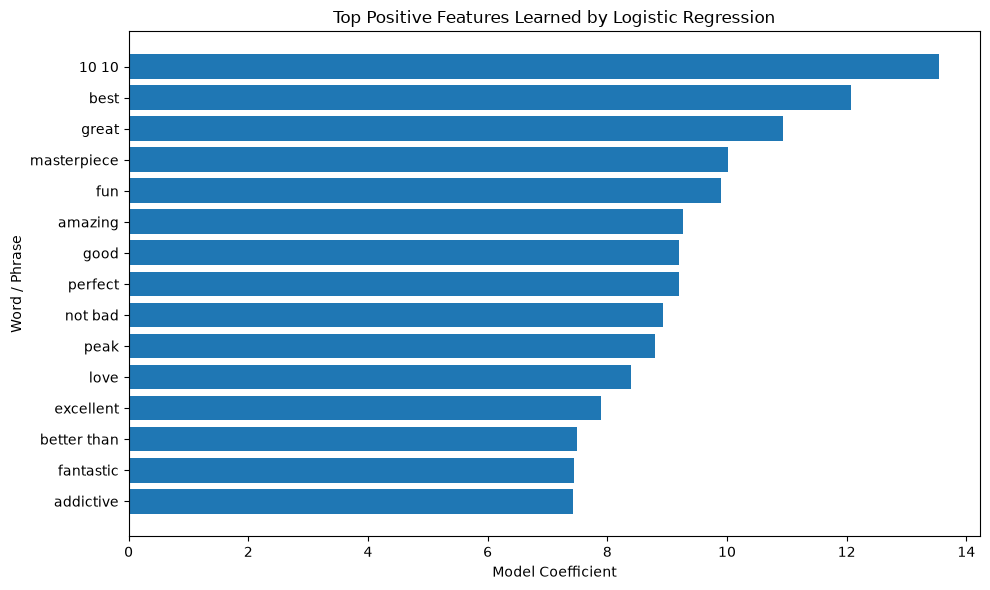

In [143]:
top_positive_words = positive_words.head(15).sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive_words["word"],
    top_positive_words["coefficient"]
)

plt.xlabel("Model Coefficient")
plt.ylabel("Word / Phrase")
plt.title("Top Positive Features Learned by Logistic Regression")

plt.tight_layout()
plt.show()

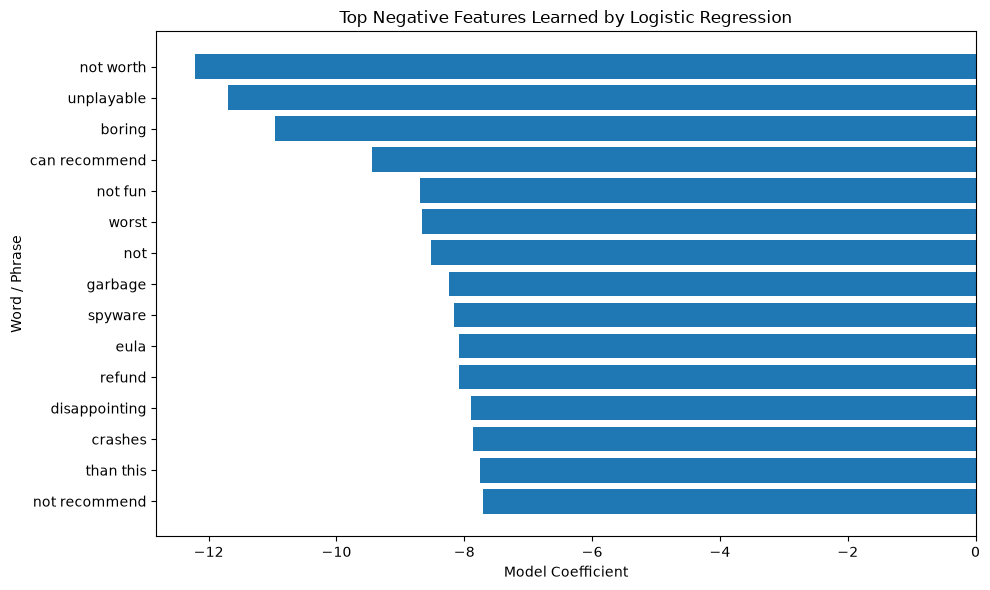

In [144]:
top_negative_words = negative_words.head(15).sort_values(
    "coefficient",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative_words["word"],
    top_negative_words["coefficient"]
)

plt.xlabel("Model Coefficient")
plt.ylabel("Word / Phrase")
plt.title("Top Negative Features Learned by Logistic Regression")

plt.tight_layout()
plt.show()

# Model Interpretability

The Logistic Regression model provides interpretable coefficients that indicate
which words and phrases are most strongly associated with positive and negative
Steam reviews.

Positive coefficients indicate features that increase the probability of a
positive review, while negative coefficients indicate features associated with
negative reviews.

This analysis helps explain how the TF-IDF based sentiment classifier makes
its predictions.

In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    
    predictions = (
        y_prob >= threshold
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.911149,0.912585,0.985730,0.947748
1,0.15,0.918743,0.926708,0.977941,0.951636
2,0.20,0.922211,0.937420,0.969566,0.953222
3,0.25,0.922814,0.945814,0.960611,0.953155
4,0.30,0.921580,0.952452,0.951573,0.952012
5,0.35,0.918846,0.958672,0.941303,0.949908
6,0.40,0.913842,0.963785,0.929531,0.946348
7,0.45,0.907619,0.968463,0.916846,0.941948
8,0.50,0.898682,0.972369,0.901679,0.935691
9,0.55,0.888312,0.976115,0.885028,0.928343


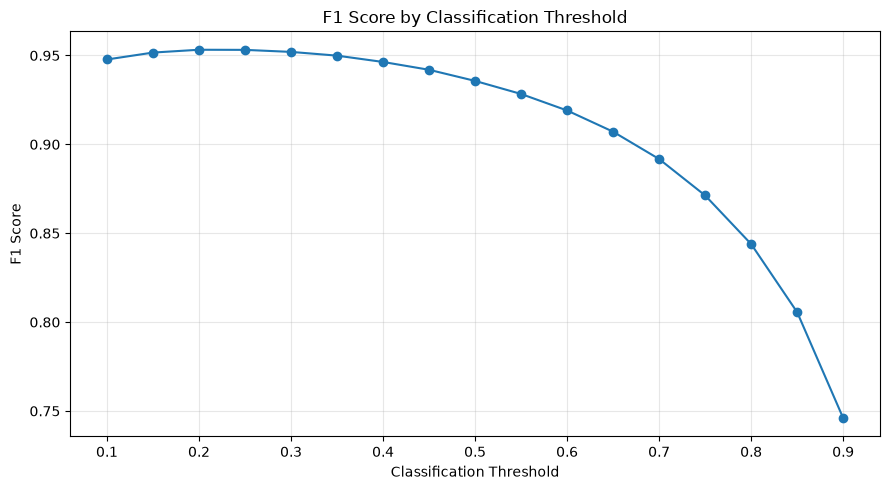

In [146]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score by Classification Threshold")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold_row

Threshold    0.200000
Accuracy     0.922211
Precision    0.937420
Recall       0.969566
F1           0.953222
Name: 2, dtype: float64

In [148]:
# Final threshold selection

final_threshold = 0.20

y_pred_final = (
    y_prob >= final_threshold
)

print("Final Threshold:", final_threshold)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

Final Threshold: 0.2

Classification Report:
              precision    recall  f1-score   support

       False       0.84      0.71      0.77     26634
        True       0.94      0.97      0.95    119273

    accuracy                           0.92    145907
   macro avg       0.89      0.84      0.86    145907
weighted avg       0.92      0.92      0.92    145907



[[ 18914   7720]
 [  3630 115643]]


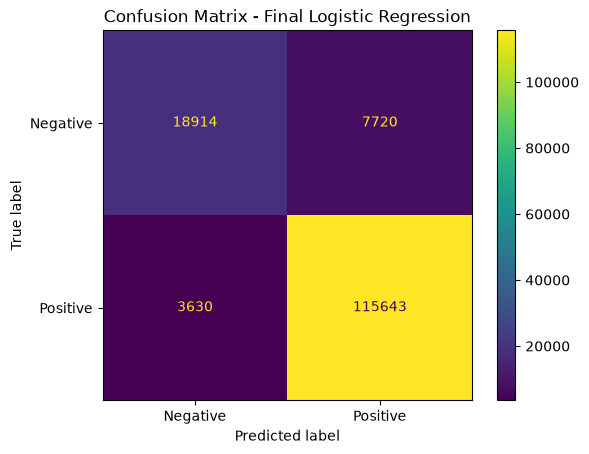

In [149]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Confusion Matrix - Final Logistic Regression")
plt.show()

In [151]:
# Final model performans raporu

final_report = classification_report(
    y_test,
    y_pred_final,
    output_dict=True
)

final_results = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        final_threshold,
        accuracy_score(y_test, y_pred_final),
        final_report["True"]["precision"],
        final_report["True"]["recall"],
        final_report["True"]["f1-score"],
        roc_auc
    ]
})

final_results

,Metric,Score
0,Threshold,0.200000
1,Accuracy,0.922211
2,Precision,0.937420
3,Recall,0.969566
4,F1 Score,0.953222
5,ROC-AUC,0.959301


# Final Model Results

After threshold optimization, a threshold of **0.20** was selected based on the highest F1 score.

The final Logistic Regression model achieved the following results:

| Metric | Score |
|---|---:|
| Threshold | 0.20 |
| Accuracy | 92.22% |
| Precision | 93.74% |
| Recall | 96.96% |
| F1 Score | 95.32% |
| ROC-AUC | 95.93% |

The optimized threshold improved the classification performance compared with the default threshold of 0.50.

The high Recall indicates that the model is able to identify most positive Steam reviews, while the high Precision shows that the majority of reviews classified as positive are actually positive.

The F1 Score of **95.32%** indicates a strong balance between Precision and Recall.

Overall, the final Logistic Regression model provides a highly effective approach for classifying Steam game reviews using TF-IDF features.

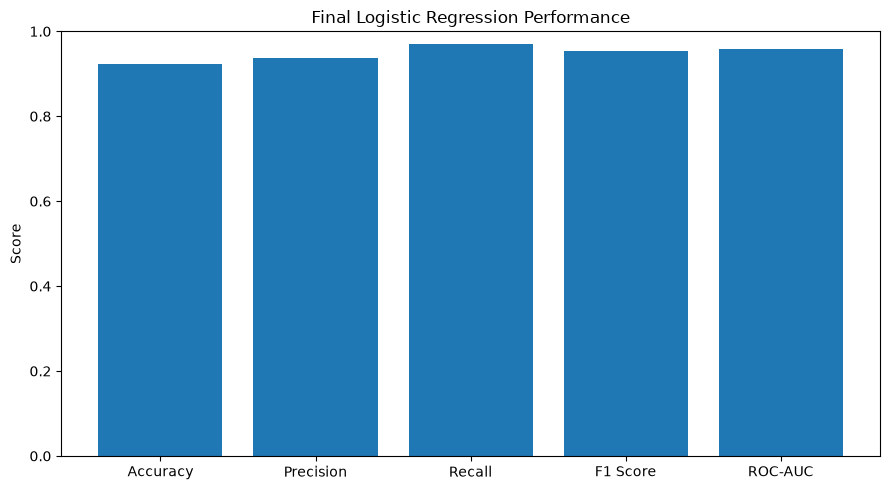

In [152]:
# Final Model Performance

metrics = {
    "Accuracy": final_results.loc[
        final_results["Metric"] == "Accuracy", "Score"
    ].iloc[0],

    "Precision": final_results.loc[
        final_results["Metric"] == "Precision", "Score"
    ].iloc[0],

    "Recall": final_results.loc[
        final_results["Metric"] == "Recall", "Score"
    ].iloc[0],

    "F1 Score": final_results.loc[
        final_results["Metric"] == "F1 Score", "Score"
    ].iloc[0],

    "ROC-AUC": final_results.loc[
        final_results["Metric"] == "ROC-AUC", "Score"
    ].iloc[0]
}

plt.figure(figsize=(9, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Logistic Regression Performance")

plt.tight_layout()
plt.show()

In [153]:
import joblib
import os

# Model klasörü oluştur
os.makedirs("../model", exist_ok=True)

# Modeli kaydet
joblib.dump(model, "../model/sentiment_model.joblib")

# TF-IDF vectorizer'ı kaydet
joblib.dump(tfidf, "../model/tfidf_vectorizer.joblib")

print("Model ve TF-IDF başarıyla kaydedildi.")

Model ve TF-IDF başarıyla kaydedildi.


In [154]:
# Game-level analiz sonuçlarını kaydet

game_analysis_filtered.to_csv(
    "../data/game_analysis.csv",
    index=True
)

print("Game analysis başarıyla kaydedildi.")

Game analysis başarıyla kaydedildi.
